# Anomaly model

Forward model with an embedded rectangular anomaly (eps_r = 20) in a two-layer background.

The background reference is the Evert two-layer solution (no anomaly). The difference between the anomaly and background responses is the target signature.

# Add multi-anomaly capability

In [1]:
import sys, os, numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# ── locate master\ from examples\<name>\ (two levels up) ─────────────────
MASTER = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..', '..'))

sys.path.insert(0, os.path.join(MASTER, 'io'))
sys.path.insert(0, os.path.join(MASTER, 'io', 'inputs'))
sys.path.insert(0, os.path.join(MASTER, 'io', 'outputs'))

# inputs
from survey import GPRSurvey
from anomalies import SphereAnomaly

# runner
from runner import ProjectPaths, run_tetgen, run_solver

# outputs
from fieldreader import AnalyticalLoader, ElfeLoader, load_elfe_batch
from postprocess import field_error, all_errors, error_stats
from visualize   import (ReceiverLinePlot, ReceiverLineErrorPlot,
                          ReceiverLineCombined, ErrorHistogramPlot)


---
## Paths

In [2]:
# ── set once per machine ───────────────────────────────────────────────────
paths = ProjectPaths(
    master_dir = MASTER,
    exec_rel   = r'elfe3D_GPR\elfe3d_gpr',
    use_wsl    = True,   # False if running from inside WSL
)

print('master   :', MASTER)
print('exec     :', paths.exec_path())


master   : f:\Projects\EMGeoInversion\elfe3D_GPR
exec     : f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\elfe3d_gpr


---
## 1 — Build and write inputs

Same background as the two-layered example, plus a `SphereAnomaly`

In [3]:
f    = 100e6
wave = 3e8 / f

BASE_DIR = os.path.join(MASTER, 'elfe3D_GPR')

survey = GPRSurvey.build(
    experiment_name="anomaly_sphere",
    base_dir=BASE_DIR,

    # Domain
    x_e=[-wave/10, 1 + wave/10],
    y_e=[-wave/10, wave/10],
    z_e=[-1.0 - wave/10/3, wave/10],

    # Materials — air + 2 earth layers
    air_eps_r=1.0,
    air_sigma=1e-16,
    layer_thicknesses=[1.0, wave/10/3],
    layer_eps_r=[4.0, 9.0],
    layer_sigma=[1e-4, 1e-3],
    layer_mu_r=[1.0, 1.0],
    layer_sigma_m=[0.0, 0.0],

    anomalies=[
        SphereAnomaly(
            center=(0.0, 0.0, -0.7),
            radius=wave/16,
            properties=(20, 1e-4, 1.0, 0.0),   # (eps_r, sigma, mu_r, sigma_m)
        )
    ],

    # Source
    ricker_central_f=f,
    num_points_per_range=1,
    antenna_position=[0.0, 0.0, 0.025],
    source_type=6,
    current_direction=1,
    num_segments=1,
    s_f=250,
    bh_f=1.0,
    box_present=False,
    box_x=[-1 + 0.75, 1 + 0.375],
    m=5,

    # Receivers
    num_receivers_inline=48,
    num_receivers_endfire=0,
    num_receivers_oblique=0,

    # Solver
    solver_type=2,
    max_ref_steps=0,
    max_unknowns=5_000_000,
    accuracy_tol=3e-5,
    output_fields_vtk=1,

    # PML
    num_pml_layers=1,
    pml_layer_thickness=wave/10,
    pml_type="lin",
    pml_decay_type=1,

    least_samples_per_wavelength=10,
)

survey.generate()

print('poly :', survey.io.poly_file)


odepths: [0.075, 0.0375, 0.025]
Source antenna length: 0.0006 m
Receiver antenna depth: -0.00015 m
[0.0, -1.0]
Written: f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\GPR_model_anomaly_sphere.poly
Written: f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\elfe3D_input.txt
Written: f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\source.txt
Written: f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\regionparameters.txt
Input generation complete.
poly : f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\GPR_model_anomaly_sphere.poly


---
## 2 — Mesh with TetGen

In [4]:
run_tetgen(paths, survey.io.poly_file)

── TetGen ────────────────────────────────────────────
   cd /mnt/f/Projects/EMGeoInversion/elfe3D_GPR/elfe3D_GPR/in && /usr/bin/tetgen -pq1.2kAaen GPR_model_anomaly_sphere.poly

Opening GPR_model_anomaly_sphere.poly.
Delaunizing vertices...
Delaunay seconds:  0.01739
Creating surface mesh ...
Surface mesh seconds:  0.003394
Constrained Delaunay...
Constrained Delaunay seconds:  0.01356
Removing exterior tetrahedra ...
Spreading region attributes.
Exterior tets removal seconds:  0.000902
Refining mesh...
Refinement seconds:  1.07411
Optimizing mesh...
Optimization seconds:  0.05804

Writing GPR_model_anomaly_sphere.1.node.
Writing GPR_model_anomaly_sphere.1.ele.
Writing GPR_model_anomaly_sphere.1.face.
Writing GPR_model_anomaly_sphere.1.edge.
Writing GPR_model_anomaly_sphere.1.vtk.
Writing GPR_model_anomaly_sphere.1.neigh.

Output seconds:  0.840175
Total running seconds:  2.00773

Statistics:

  Input points: 2804
  Input facets: 5247
  Input segments: 8049
  Input holes: 0
  Input re

---
## 3 — Run solver

In [5]:
run_solver(paths,survey)

── elfe3d_gpr ────────────────────────────────────────
   wsl bash -c cd /mnt/f/Projects/EMGeoInversion/elfe3D_GPR/elfe3D_GPR && /mnt/f/Projects/EMGeoInversion/elfe3D_GPR/elfe3D_GPR/elfe3d_gpr

***************************************
GPR forward modelling with elfe3D_GPR
***************************************
Your forward problem is solved with
 MUMPS
*************************************
Reading refinement information
Your mesh will be refined
 for             0 refinement steps
 or until     5000000 unknowns
 with error estim. method           3
 with refinement strategy           1
Your output files will be generated in: /out
Field components in the domain will be in *.vtk file in: /in
*************************************
Reading model definitions


Your input meshfile is called
 in/GPR_model_anomaly_sphere.                      
Your mesh has
       52265 Nodes
      315786 Elements
      371588 Edges (dof)
*************************************
Assembling connectivity arrays
Calculating interpolation coefficients
Obtaining model properties
*************************************
Source parameters:
 CSTYPE           6
 source-start coordinates:
  -2.9999999999999997E-004   0.0000000000000000        2.5000000000000001E-002
 source-end coordinates  
   2.9999999999999997E-004   0.0000000000000000        2.5000000000000001E-002
 source moment               1.0000000000000000     
Segmented line source
Number of source edges:
           1
Source edges and nodes:
      316089
         161         162
*************************************
Detecting surface edges
Check if PEC present
Check if PML present
Detecting PML elements
Number of PML elements:
       52175
Number of non-PML elements:
      263611
To Check, number of non-PML elements

---
## 4 — Load results

In [6]:
result_txt = survey.io.output_dir / 'electric_fields_receiver_line.txt'
print('reading:', result_txt)

ef = ElfeLoader(
    filepath    = str(result_txt),
    label       = 'elfe3D layered sphere anomaly',
    num_endfire = 48,
).endfire()

print(f'r : {ef.r.min():.3f} – {ef.r.max():.3f} m   ({len(ef.r)} receivers)')


reading: f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\out_anomaly_sphere\electric_fields_receiver_line.txt
r : 0.100 – 1.000 m   (48 receivers)


---
## 5 — Background reference

In [7]:
# Background reference = two-layer model without the anomaly
# Same CSV as the two-layered example — the anomaly response is the
# difference between this and the anomaly run.
ANALYTICAL_DIR = r'F:\Projects\EMGeoInversion\elfe3D_GPR\data\data_semi_analytical'

bg = AnalyticalLoader(
    os.path.join(ANALYTICAL_DIR, 'Exx_single_freq_4_9_100MHz_NR.csv'),
    label='Background (Evert)',
).endfire()


---
## 6 — Anomaly vs background comparison

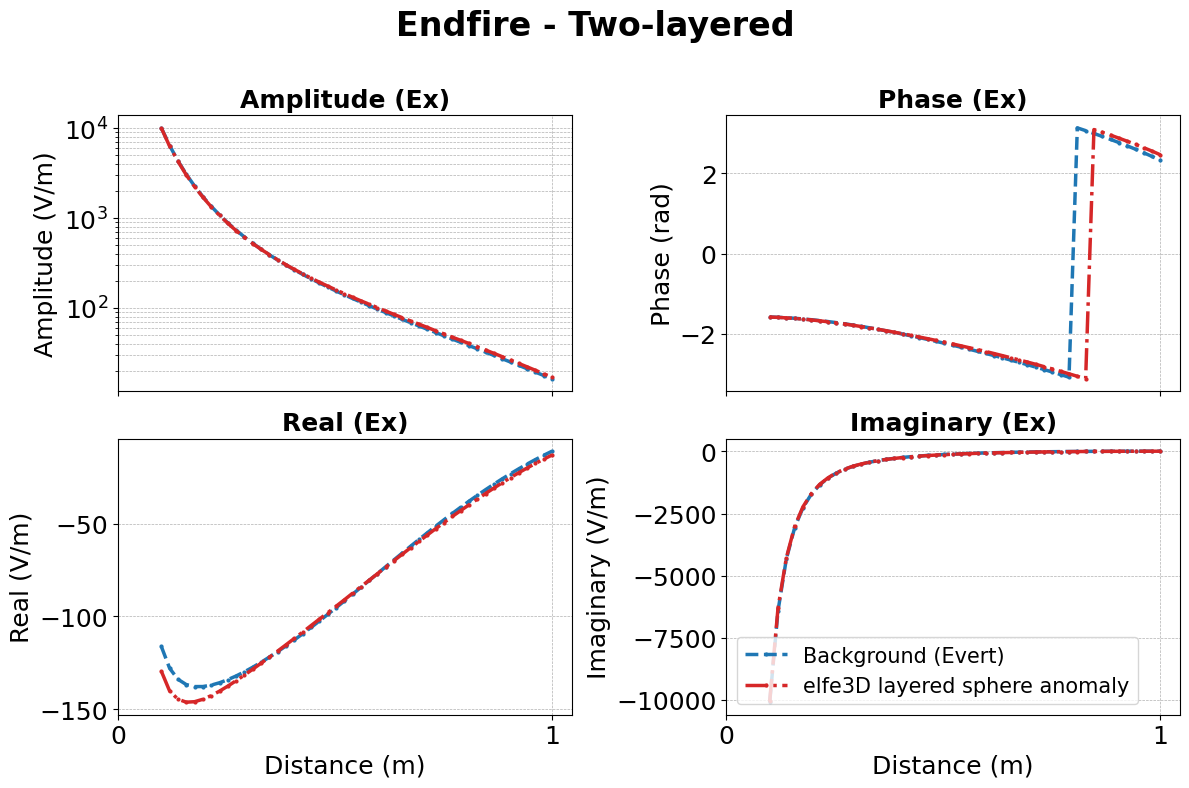

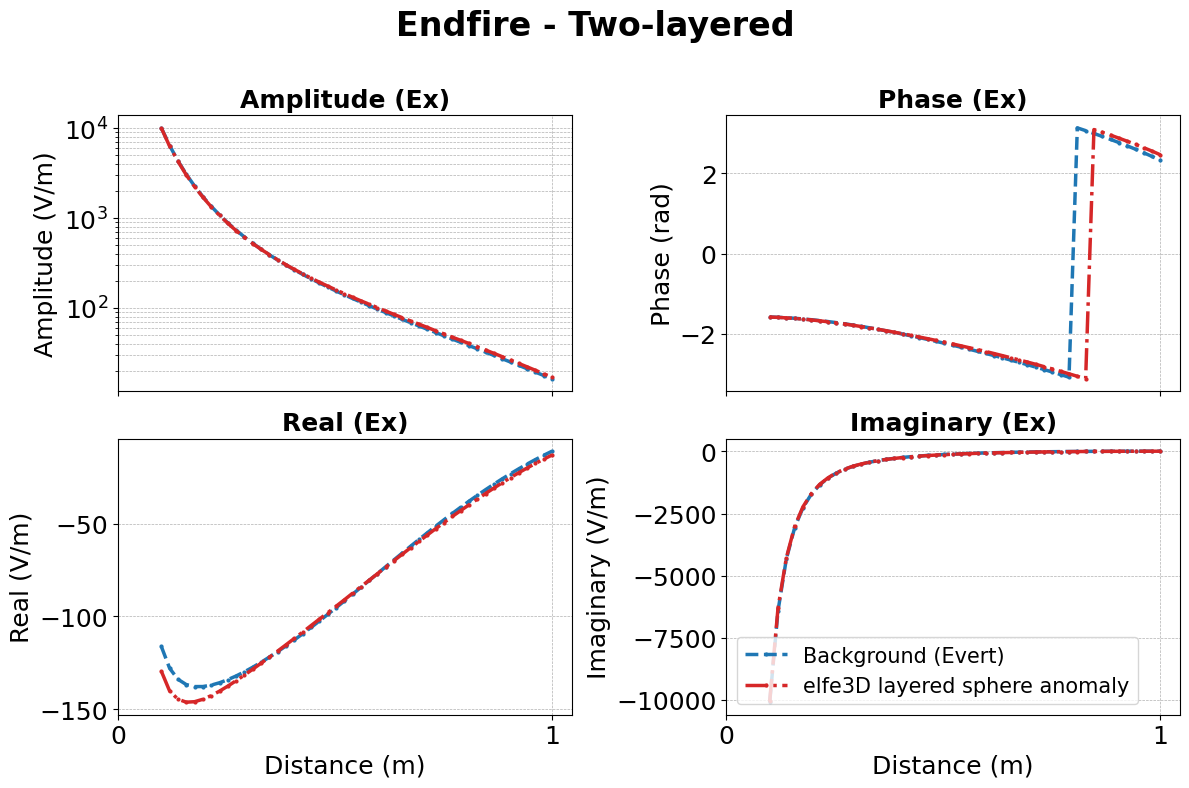

In [8]:
ReceiverLinePlot([bg, ef]).plot(suptitle="Endfire - Two-layered")

## Anomaly response  (difference from background)

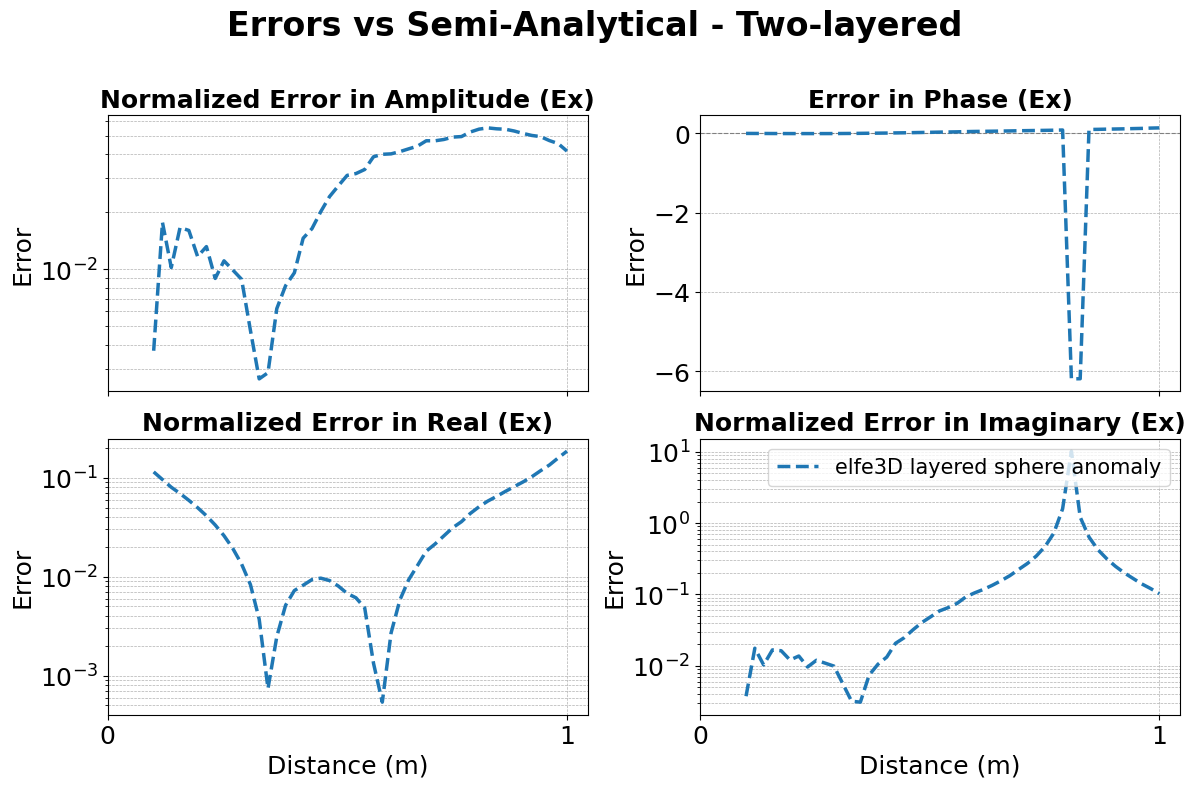

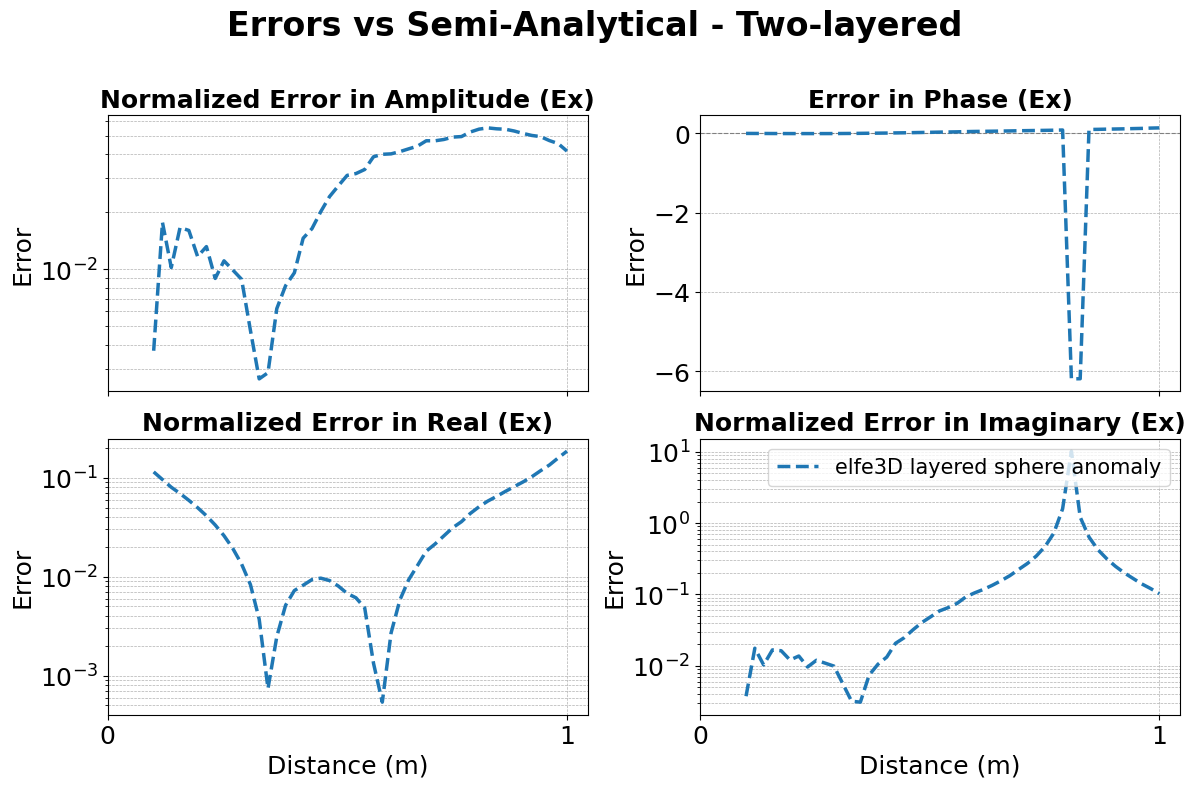

In [9]:
ReceiverLineErrorPlot([ef], reference=bg).plot(suptitle="Errors vs Semi-Analytical - Two-layered")

## Combined (fields + anomaly response)

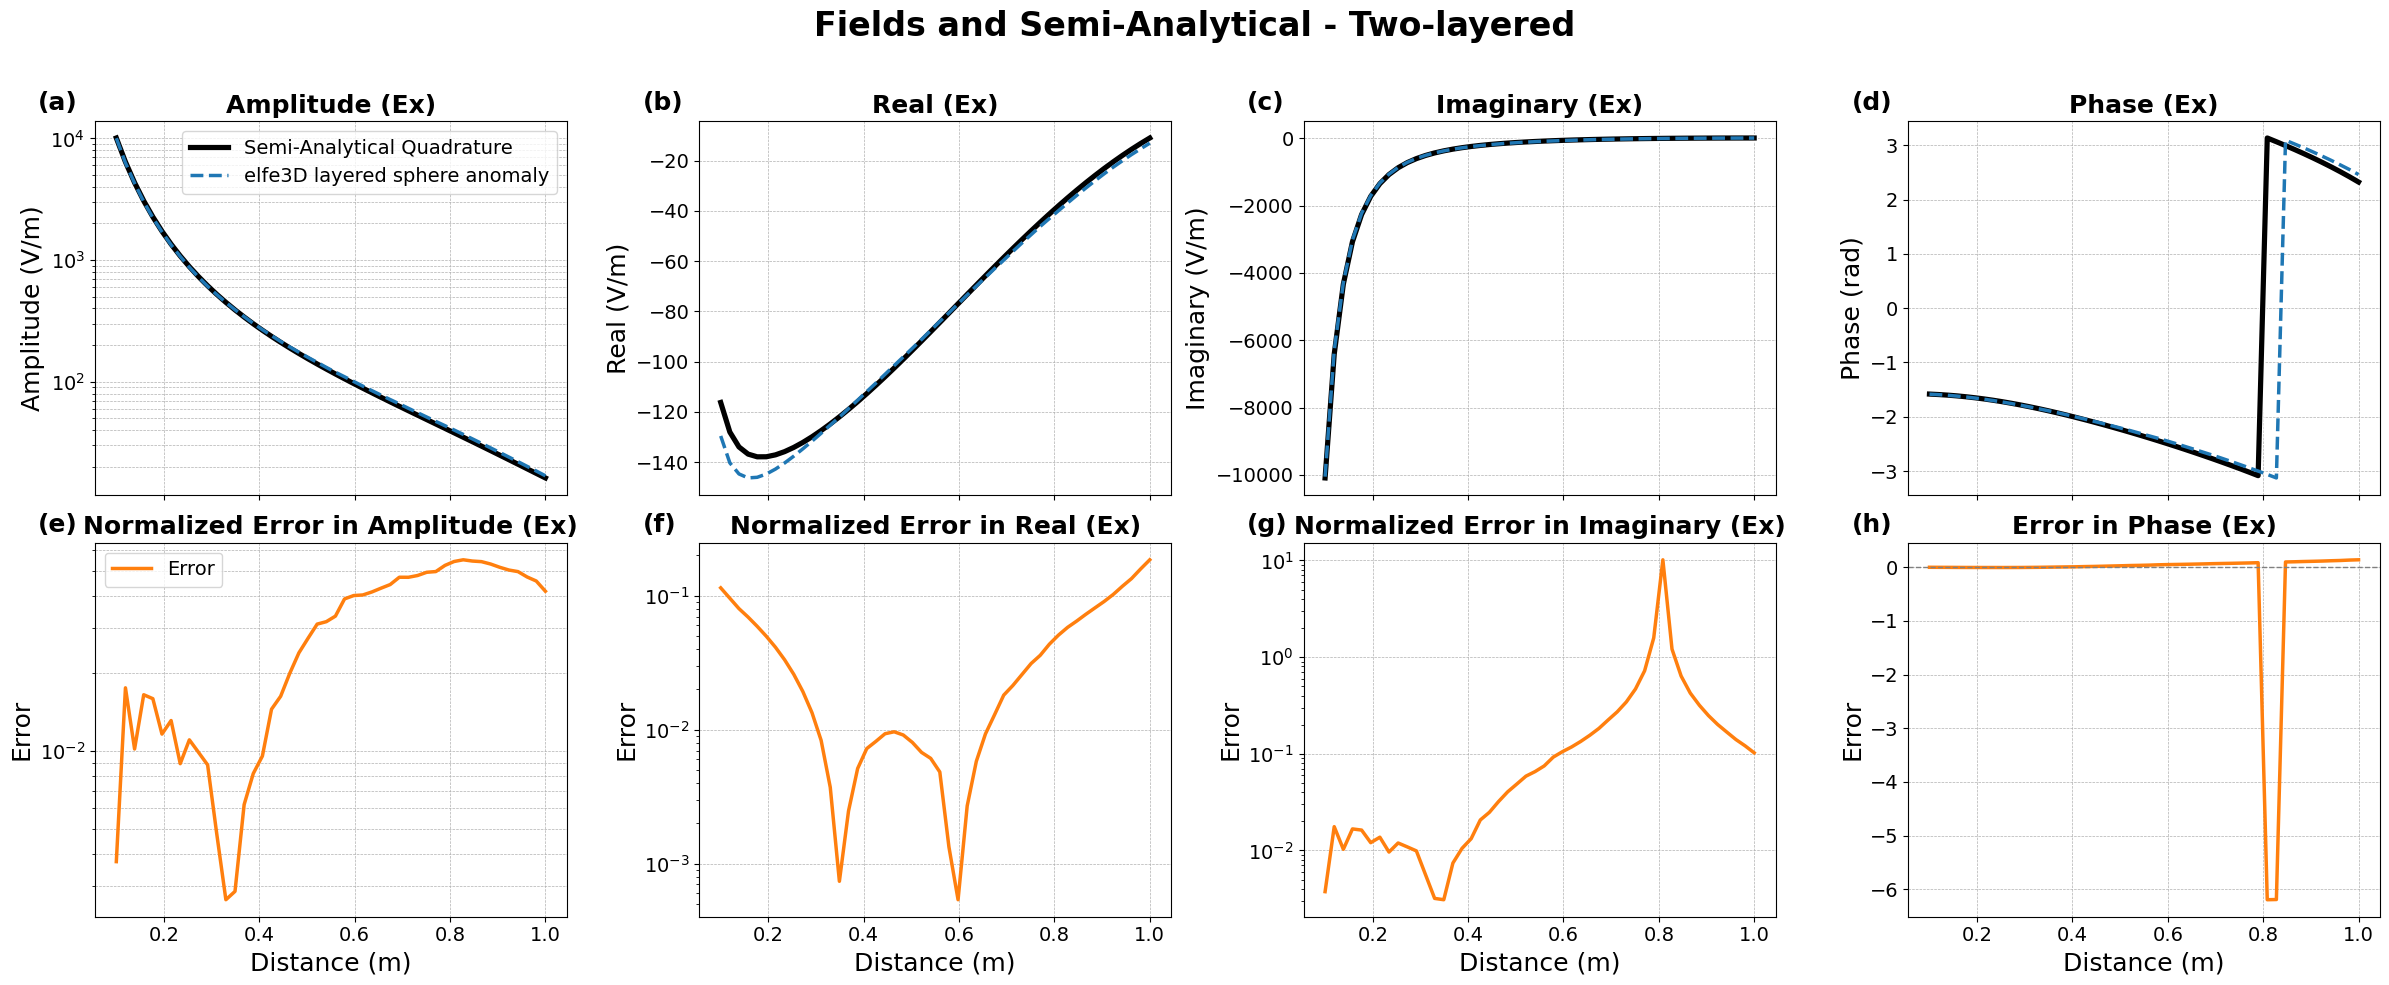

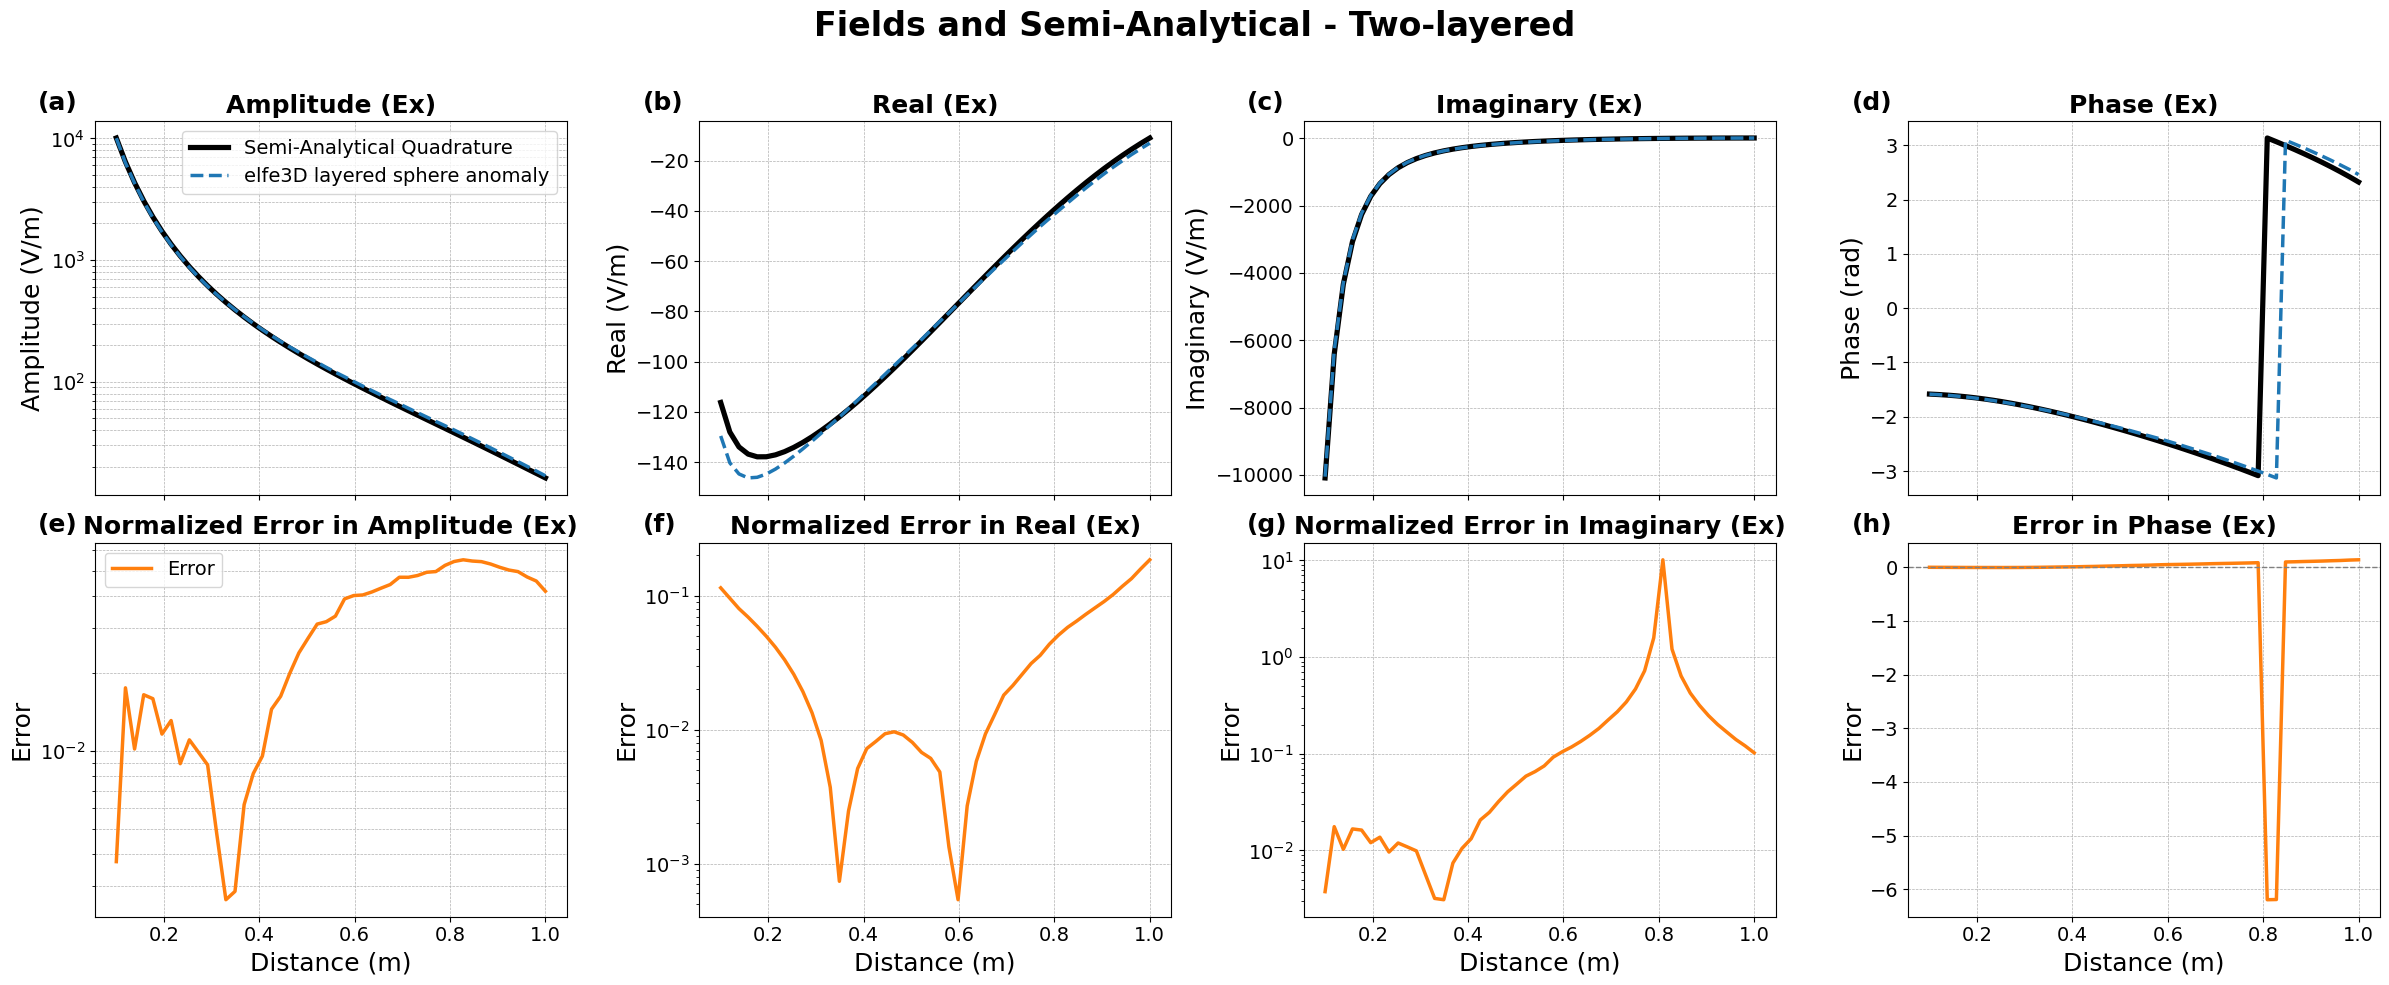

In [10]:
ReceiverLineCombined(ef, bg).plot(suptitle="Fields and Semi-Analytical - Two-layered")

## Response distribution histogram

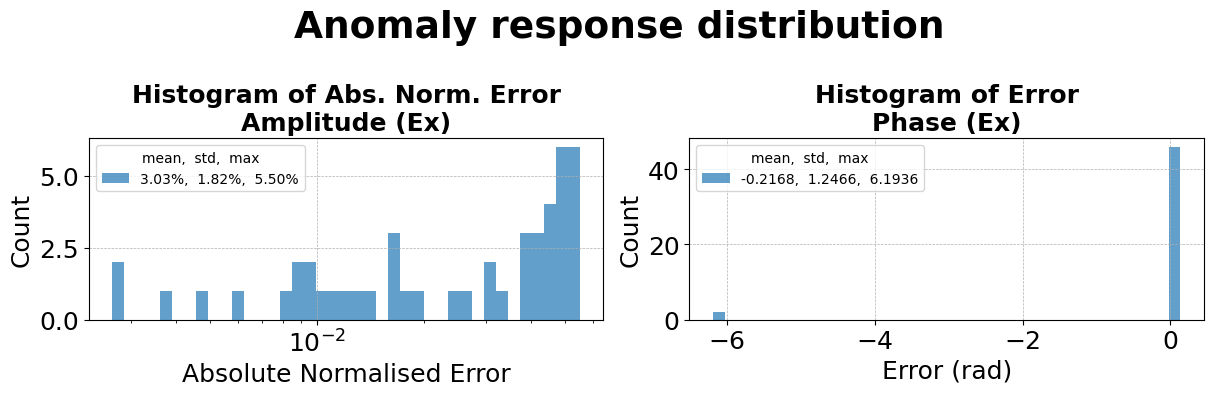

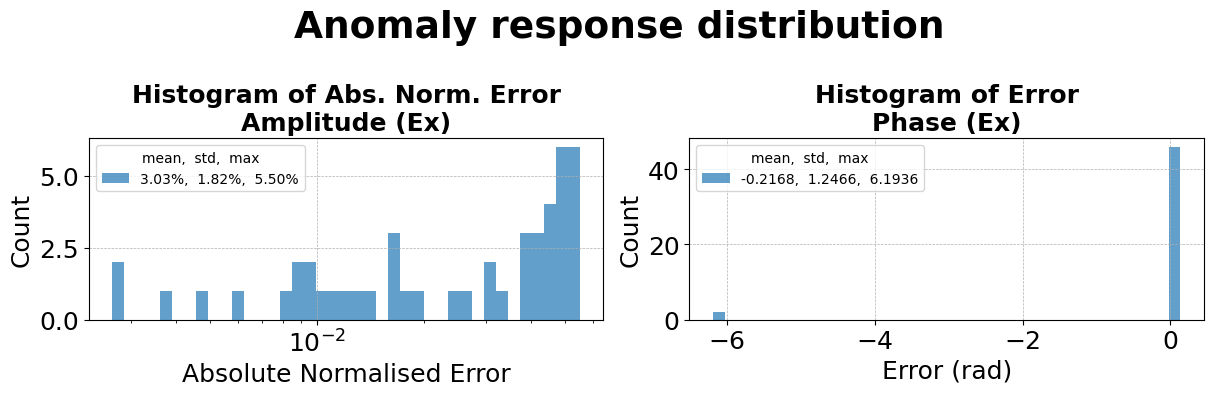

In [11]:
ErrorHistogramPlot([ef], reference=bg).plot(suptitle='Anomaly response distribution',)


## Printed anomaly response summary

In [12]:
qty_names = ['Amplitude', 'Phase', 'Real', 'Imaginary']
print('Anomaly response (relative to two-layer background)\n')
for qi, name in enumerate(qty_names):
    err = field_error(bg, ef, qi)
    m, s, mx = error_stats(err)
    scale, unit = (100, '%') if qi != 1 else (1, 'rad')
    print(f'  {name:12s}:  mean={m*scale:.3f}{unit}  '
          f'std={s*scale:.3f}{unit}  max={mx*scale:.3f}{unit}')


Anomaly response (relative to two-layer background)

  Amplitude   :  mean=3.034%  std=1.815%  max=5.503%
  Phase       :  mean=-0.217rad  std=1.247rad  max=6.194rad
  Real        :  mean=4.202%  std=4.509%  max=18.554%
  Imaginary   :  mean=38.916%  std=145.813%  max=1016.744%
